# Lista de Exercícios C13 — Resolução

##Nome: Antonio Feliciano da Silveira Neto

In [3]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.3 MB/s eta 0:00:00


In [4]:
import numpy as np
import control as cnt
import matplotlib.pyplot as plt

def malha_fechada(K, tau, theta, Kp, Ti, Td, n_pade=10):
    """Monta a FT de malha fechada: planta FOPDT (K,tau,theta) + PID (Kp,Ti,Td)."""
    H = cnt.tf([K], [tau, 1])
    num_p, den_p = cnt.pade(theta, n_pade)
    Hp = cnt.tf(num_p, den_p)
    Hkp = cnt.tf([Kp], [1])
    Hki = cnt.tf([Kp], [Ti, 0])
    Hkd = cnt.tf([Kp*Td, 0], [1])
    Hctrl = cnt.parallel(Hkp, Hki, Hkd)
    Hplanta = cnt.series(H, Hp)
    Hol = cnt.series(Hplanta, Hctrl)
    return cnt.feedback(Hol, 1)

def zn(K,tau,theta):
    return 1.2*tau/(K*theta), 2*theta, 0.5*theta

def chr0(K,tau,theta):
    return 0.6*tau/(K*theta), tau, 0.5*theta

def chr20(K,tau,theta):
    return 0.95*tau/(K*theta), 1.35*tau, 0.47*theta

def imc(K,tau,theta,lam):
    return (1/K)*(tau/(lam+theta)), tau, theta/2


## Questão 1 — Estufa agrícola (identificação pelo método de Smith)

**a) Identificação da planta**

Dados do ensaio: Δu = 0,20 ; ΔT = 12 °C ; t₁ (28,3%) = 15 s ; t₂ (63,2%) = 42 s

Método de Smith (dois pontos):

- τ = 1,5·(t₂ − t₁) = 1,5·(42 − 15) = **40,5 s**
- θ = t₂ − τ = 42 − 40,5 = **1,5 s**
- K = ΔT/Δu = 12/0,20 = **60**

$$G(s)=\dfrac{60\,e^{-1,5s}}{40,5s+1}$$

**b) Kp, Ti, Td**


In [5]:
K,tau,theta = 60,40.5,1.5
print("Ziegler-Nichols (malha aberta):", zn(K,tau,theta))
print("CHR sem sobrevalor:            ", chr0(K,tau,theta))
print("IMC (lambda = theta):          ", imc(K,tau,theta,theta))


Ziegler-Nichols (malha aberta): (0.54, 3.0, 0.75)
CHR sem sobrevalor:             (0.27, 40.5, 0.75)
IMC (lambda = theta):           (0.225, 40.5, 0.75)


Resultados:

| Método | Kp | Ti (s) | Td (s) |
|---|---|---|---|
| Ziegler-Nichols | 0,54 | 3,0 | 0,75 |
| CHR sem sobrevalor | 0,27 | 40,5 | 0,75 |
| IMC (λ = θ) | 0,225 | 40,5 | 0,75 |

**c) Resposta ao degrau unitário**


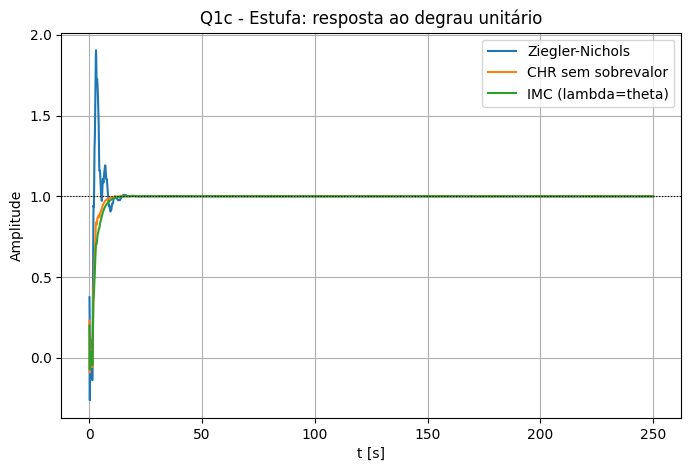

In [6]:
sets = {
    "Ziegler-Nichols": zn(K,tau,theta),
    "CHR sem sobrevalor": chr0(K,tau,theta),
    "IMC (lambda=theta)": imc(K,tau,theta,theta),
}
t = np.linspace(0,250,3000)
plt.figure(figsize=(8,5))
for nome,(Kp,Ti,Td) in sets.items():
    Hcl = malha_fechada(K,tau,theta,Kp,Ti,Td)
    tt,y = cnt.step_response(Hcl,t)
    plt.plot(tt,y,label=nome)
plt.axhline(1,color="k",ls=":",lw=0.8)
plt.title("Q1c - Estufa: resposta ao degrau unitário")
plt.xlabel("t [s]"); plt.ylabel("Amplitude"); plt.legend(); plt.grid(True)
plt.show()


**d) Análise comparativa**

O Ziegler-Nichols resulta no maior Kp (0,54) e no menor Ti, produzindo uma resposta bem mais rápida, porém oscilatória e com sobrevalor elevado — típico do método, que visa uma razão de decaimento de 1/4 e não robustez. O CHR sem sobrevalor e o IMC (λ=θ) produzem respostas suaves, sem oscilação, às custas de um tempo de acomodação maior; o IMC é o mais conservador dos três (menor Kp), por construção — o parâmetro λ é justamente o ajuste do compromisso velocidade × robustez.

## Questão 2 — Por que ZN e CHR não são o ajuste final?

Ziegler–Nichols e CHR são métodos **empíricos baseados em um modelo aproximado de 1ª ordem com atraso (FOPDT)**, extraído de um único ensaio em degrau. Suas fórmulas foram calibradas para um comportamento "típico" (ex.: razão de decaimento de 1/4 no caso do ZN), mas não levam em conta:

- não linearidades do processo real, saturação de atuadores, ruído de medição;
- variações de ponto de operação (o processo real não é LIT como o modelo assumido);
- robustez a incertezas de modelo (o próprio ensaio de identificação já é aproximado);
- múltiplas exigências de desempenho ao mesmo tempo (velocidade, sobrevalor, rejeição a perturbação, esforço de controle).

Por isso, servem como **ponto de partida** — um "chute" numérico razoável — que depois precisa ser refinado por ajuste fino manual, métodos mais robustos (IMC, otimização, auto-tuning) ou testes em campo, até atingir o desempenho realmente desejado para aquele processo específico.

## Questão 3 — Ziegler-Nichols (malha aberta) para dois sistemas IoT

In [7]:
print("a) Irrigacao:", zn(2.5,20,4))
print("b) Esteira:  ", zn(1.8,3,0.8))


a) Irrigacao: (2.4, 8, 2.0)
b) Esteira:   (2.4999999999999996, 1.6, 0.4)


| Sistema | K | τ (s) | θ (s) | Kp | Ti (s) | Td (s) |
|---|---|---|---|---|---|---|
| a) Irrigação | 2,5 | 20 | 4 | 2,4 | **8** | 2 |
| b) Esteira | 1,8 | 3 | 0,8 | 2,5 | **1,6** | 0,4 |

**Comparação Ti vs θ:** pela própria fórmula de ZN, Ti = 2θ sempre, então a razão Ti/θ é igual (=2) nos dois casos — isso não diferencia a sensibilidade.

O que diferencia é o **peso relativo** de um atraso adicional de 300 ms de comunicação Wi-Fi:

- Irrigação: 0,3/4 = 7,5 % de acréscimo em θ
- Esteira: 0,3/0,8 = 37,5 % de acréscimo em θ

A esteira transportadora é a mais sensível: seu θ já é pequeno frente à constante de tempo (θ/τ = 0,27, contra 0,20 da irrigação), e um atraso adicional de 300 ms representa um salto proporcional muito maior no atraso total do laço. Como a margem de fase de um controlador PID cai rapidamente quando o atraso morto aumenta em relação ao período de oscilação do laço, o sistema da esteira corre mais risco de ficar oscilatório ou instável com esse atraso extra de comunicação do que o de irrigação.

## Questão 4 — Armário de rede (data center IoT)

G(s) = 1,5·e^(−1s) / (6s+1) → K=1,5, τ=6 s, θ=1 s

In [8]:
K,tau,theta = 1.5,6,1
print("a) CHR sem sobrevalor:", chr0(K,tau,theta))
print("b) CHR com 20% sobrevalor:", chr20(K,tau,theta))


a) CHR sem sobrevalor: (2.4, 6, 0.5)
b) CHR com 20% sobrevalor: (3.7999999999999994, 8.100000000000001, 0.47)


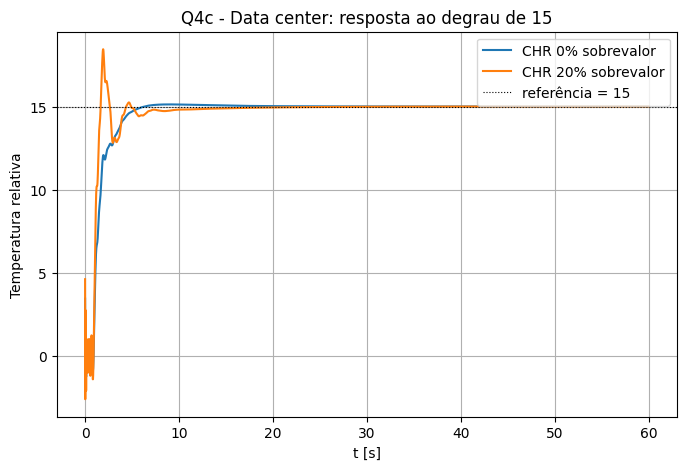

In [9]:
sets2 = {"CHR 0% sobrevalor": chr0(K,tau,theta), "CHR 20% sobrevalor": chr20(K,tau,theta)}
t2 = np.linspace(0,60,3000)
plt.figure(figsize=(8,5))
for nome,(Kp,Ti,Td) in sets2.items():
    Hcl = malha_fechada(K,tau,theta,Kp,Ti,Td)
    tt,y = cnt.step_response(Hcl,t2)
    plt.plot(tt,15*y,label=nome)
plt.axhline(15,color="k",ls=":",lw=0.8,label="referência = 15")
plt.title("Q4c - Data center: resposta ao degrau de 15")
plt.xlabel("t [s]"); plt.ylabel("Temperatura relativa"); plt.legend(); plt.grid(True)
plt.show()


**d)** Kp(0%) = 2,4 é bem menor que Kp(20%) = 3,8. O ajuste de 20% de sobrevalor é mais rápido, mas deixa a temperatura passar do valor-alvo antes de estabilizar. Como no data center **ultrapassar a temperatura-alvo (mesmo temporariamente) acelera o desgaste dos equipamentos**, o critério de segurança/confiabilidade pesa mais do que velocidade — a recomendação é o ajuste **CHR sem sobrevalor (Kp=2,4; Ti=6 s; Td=0,5 s)**, que garante que a temperatura nunca excede o setpoint durante a subida, mesmo custando um tempo de acomodação maior.

## Questão 5 — Estufa (Bloco 0): K=60, τ=40,5 s, θ=1,5 s — IMC

In [10]:
K,tau,theta = 60,40.5,1.5
lam1, lam2 = 1.5*theta, 4*theta
print("a) IMC lambda=1.5*theta:", imc(K,tau,theta,lam1))
print("b) IMC lambda=4*theta:  ", imc(K,tau,theta,lam2))


a) IMC lambda=1.5*theta: (0.18000000000000002, 40.5, 0.75)
b) IMC lambda=4*theta:   (0.09000000000000001, 40.5, 0.75)


| λ | Kp | Ti (s) | Td (s) |
|---|---|---|---|
| 1,5θ = 2,25 s | 0,18 | 40,5 | 0,75 |
| 4θ = 6 s | 0,09 | 40,5 | 0,75 |


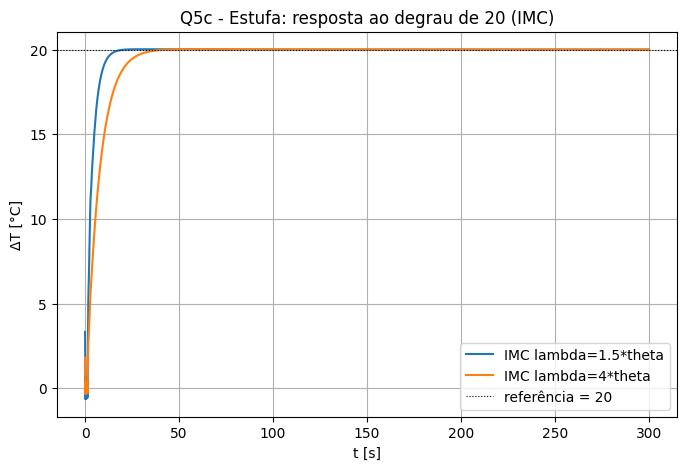

In [11]:
sets3 = {"IMC lambda=1.5*theta": imc(K,tau,theta,lam1), "IMC lambda=4*theta": imc(K,tau,theta,lam2)}
t3 = np.linspace(0,300,3000)
plt.figure(figsize=(8,5))
for nome,(Kp,Ti,Td) in sets3.items():
    Hcl = malha_fechada(K,tau,theta,Kp,Ti,Td)
    tt,y = cnt.step_response(Hcl,t3)
    plt.plot(tt,20*y,label=nome)
plt.axhline(20,color="k",ls=":",lw=0.8,label="referência = 20")
plt.title("Q5c - Estufa: resposta ao degrau de 20 (IMC)")
plt.xlabel("t [s]"); plt.ylabel("ΔT [°C]"); plt.legend(); plt.grid(True)
plt.show()


**d)** λ é o parâmetro de projeto do IMC: é a constante de tempo desejada para a malha fechada.

- λ pequeno (1,5θ) → Kp maior → resposta **mais rápida**, mas mais sensível a erros de modelo e a ruído/perturbações (mais "agressivo").
- λ grande (4θ) → Kp menor → resposta **mais lenta**, porém mais **robusta**: menos sensível a incertezas do modelo e menos excitada por perturbações rápidas.

Se a estufa está sujeita a rajadas de vento que abrem/fecham as telas de ventilação com frequência (perturbações rápidas e repetidas), um controlador muito agressivo (λ pequeno) tende a reagir de forma exagerada a cada rajada, podendo gerar oscilações ("caça" do atuador). Por isso, para esse cenário a escolha recomendada é **λ = 4θ**: resposta mais suave e mais robusta a essas perturbações frequentes, mesmo sacrificando velocidade de resposta.